Data head:
   Time (s)  Drive Voltage (V)  Bias Voltage (V)  Resistor Voltage Drop (V)  \
0  0.297001               -4.0         -6.730983                   2.730512   
1  0.431000               -3.8         -6.392568                   2.593317   
2  0.534000               -3.6         -6.056766                   2.456775   
3  0.643001               -3.4         -5.719004                   2.319906   
4  0.752000               -3.2         -5.385163                   2.184671   

   Current (A)  Raw AO0 (V)  Raw AI0 (V)  Raw AI1 (V)  
0     0.001258         -4.0    -4.000471    -1.269959  
1     0.001195         -3.8    -3.799251    -1.205934  
2     0.001132         -3.6    -3.599991    -1.143216  
3     0.001069         -3.4    -3.399098    -1.079192  
4     0.001007         -3.2    -3.200492    -1.015821  

Column names:
Index(['Time (s)', 'Drive Voltage (V)', 'Bias Voltage (V)',
       'Resistor Voltage Drop (V)', 'Current (A)', 'Raw AO0 (V)',
       'Raw AI0 (V)', 'Raw AI1 (V)'],

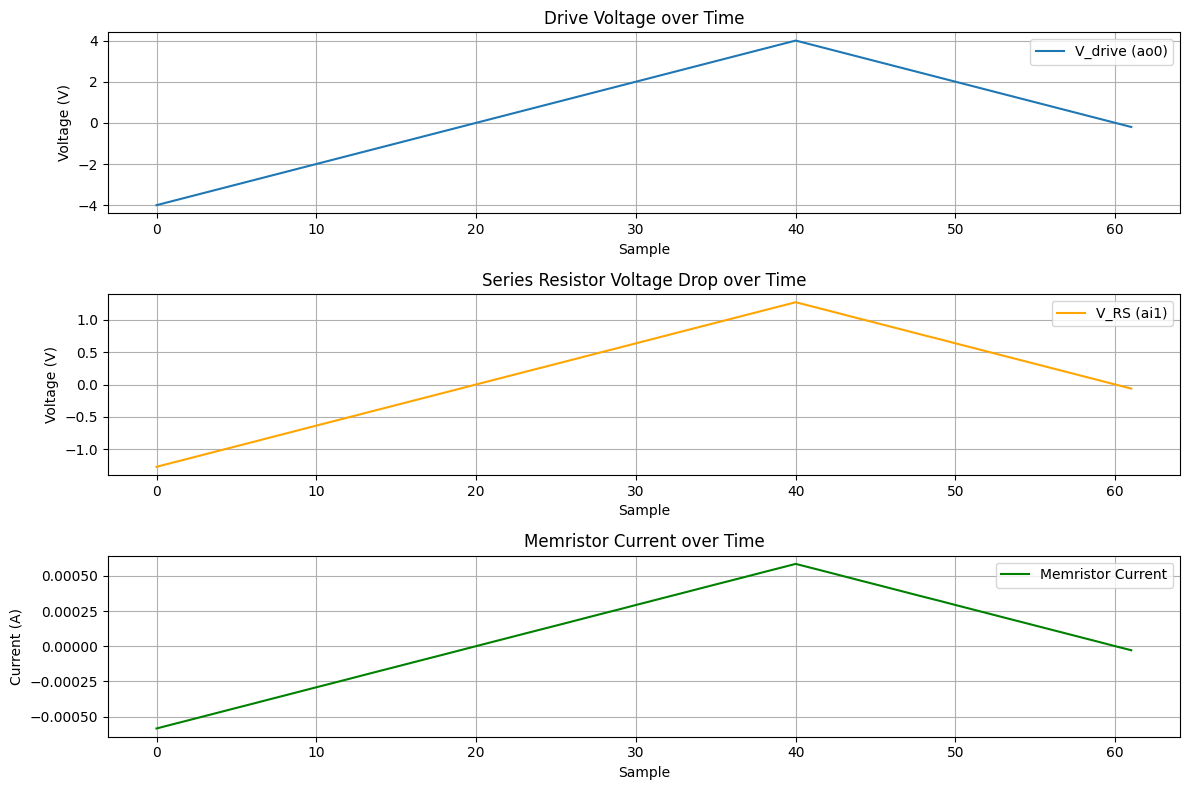

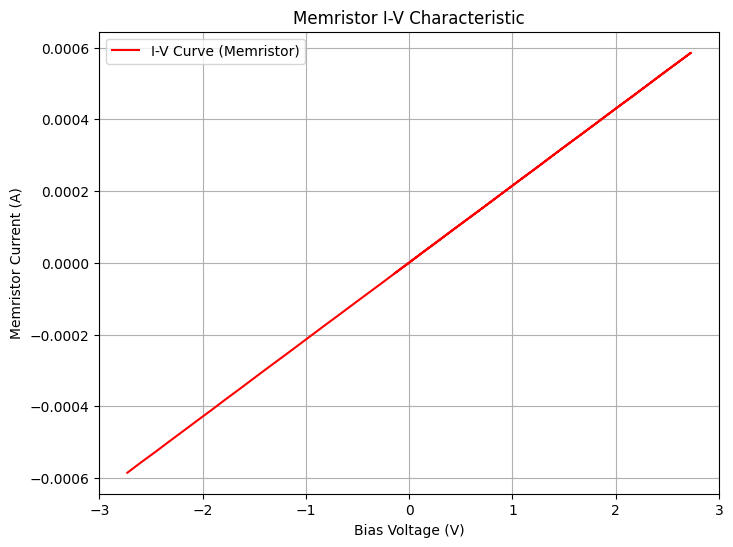

In [12]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define the series resistance (RS) - USER INPUT REQUIRED
# This value is crucial for calculating the current and bias voltage.
# Please replace the placeholder with the actual value of your series resistor in Ohms.
RS = 2170  # Example value: 1 kOhm. Please update this with the correct value.

# File path for the data
file_path = 'task1.txt'

# Read the tab-separated data
# Assuming the first row contains headers. If not, adjust header=None and manually assign column names.
df = pd.read_csv(file_path, sep='\t')

# Display the first few rows and column names to verify
print("Data head:")
print(df.head())
print("\nColumn names:")
print(df.columns)

# Extract relevant columns
# Assuming 'ai0', 'ai1', and 'ao0' are the column names as specified.
# Please verify these names from the print(df.columns) output and adjust if necessary.

try:
    Vdrive = df['Raw AO0 (V)'] # Corrected column name for drive voltage
    V_RS = df['Raw AI1 (V)']   # Corrected column name for series resistor voltage drop
    # ai0 is mentioned, but its role isn't explicitly defined for calculations yet. 
    # It might be another measured voltage or current if multiple channels are used.
    # For now, we focus on Vdrive and V_RS for current and bias voltage calculations.
except KeyError as e:
    print(f"Error: Missing expected column: {e}. Please check the 'out.txt' file and adjust column names if necessary.")
    exit()

# Calculate the current in the memristor
# I = V_RS / RS
I_memristor = V_RS / RS

# Calculate the bias voltage across the memristor
# Vbias = Vdrive - I * RS. This simplifies to Vbias = Vdrive - V_RS
Vbias = Vdrive - V_RS

# Add calculated values to the DataFrame
df['I_memristor'] = I_memristor
df['Vbias'] = Vbias

# Display calculated values
print("\nData with calculated values:")
print(df.head())

# Plotting the data
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(Vdrive, label='V_drive (ao0)')
plt.xlabel('Sample')
plt.ylabel('Voltage (V)')
plt.title('Drive Voltage over Time')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(V_RS, label='V_RS (ai1)', color='orange')
plt.xlabel('Sample')
plt.ylabel('Voltage (V)')
plt.title('Series Resistor Voltage Drop over Time')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(I_memristor, label='Memristor Current', color='green')
plt.xlabel('Sample')
plt.ylabel('Current (A)')
plt.title('Memristor Current over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(Vbias, I_memristor, label='I-V Curve (Memristor)', color='red')
plt.xlabel('Bias Voltage (V)')
plt.ylabel('Memristor Current (A)')
plt.title('Memristor I-V Characteristic')
plt.legend()
plt.grid(True)
plt.show()



In [3]:
# Calculate the slope of the I-V curve (dI/dVbias)
# Using numpy.gradient for numerical differentiation
slope_iv_curve = np.gradient(df['I_memristor'], df['Vbias'])

# Calculate the inverse of the slope (dVbias/dI)
# This represents the differential resistance
inverse_slope_iv_curve = 1 / slope_iv_curve

print("\nSlope of the I-V curve (dI/dVbias) - first 5 values:")
print(slope_iv_curve[:5])

print("\nInverse of the slope (Differential Resistance - dVbias/dI) - first 5 values:")
print(inverse_slope_iv_curve[:5])

# You can also plot these if needed
# plt.figure(figsize=(10, 6))
# plt.plot(df['Vbias'], slope_iv_curve, label='dI/dVbias')
# plt.xlabel('Bias Voltage (V)')
# plt.ylabel('Slope (A/V)')
# plt.title('Slope of I-V Curve')
# plt.grid(True)
# plt.legend()
# plt.show()

# plt.figure(figsize=(10, 6))
# plt.plot(df['Vbias'], inverse_slope_iv_curve, label='Differential Resistance', color='purple')
# plt.xlabel('Bias Voltage (V)')
# plt.ylabel('Resistance (Ohms)')
# plt.title('Differential Resistance of Memristor')
# plt.grid(True)
# plt.legend()
# plt.show()




Slope of the I-V curve (dI/dVbias) - first 5 values:
[0.00021698 0.00021377 0.00021377 0.00021537 0.00021455]

Inverse of the slope (Differential Resistance - dVbias/dI) - first 5 values:
[4608.66070708 4677.86868703 4677.86868703 4643.25560068 4660.89626271]



Polynomial fit coefficients for I-V curve (degree=1):
Resistance: 4.663e+03 Ohm


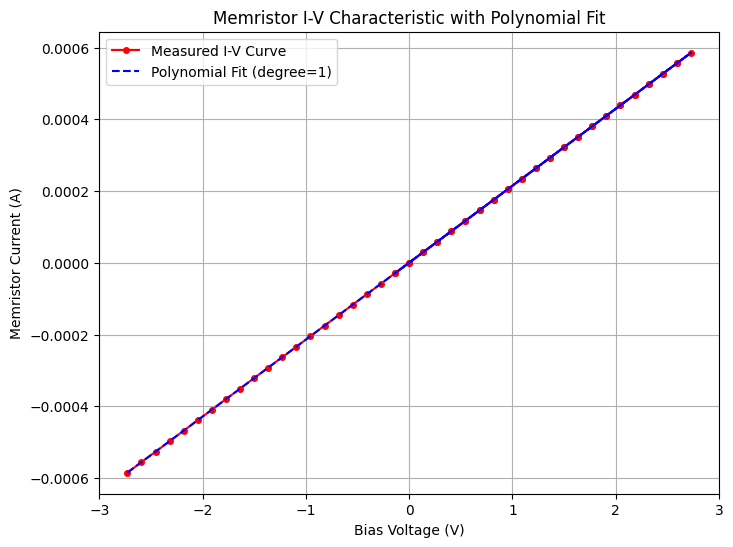

In [8]:
# Perform a polynomial fit for the I-V curve (I_memristor vs Vbias)
# You can change the degree of the polynomial as needed.
degree = 1 # Starting with a linear fit. Change to 2, 3, etc., for higher-order polynomial fits.

coefficients_iv_curve = np.polyfit(df['Vbias'], df['I_memristor'], degree)

print(f"\nPolynomial fit coefficients for I-V curve (degree={degree}):")
# Print coefficients based on the degree
if degree == 1:
    print(f"Resistance: {(1/coefficients_iv_curve[0]):.4} Ohm")
else:
    print(f"  Coefficients: {coefficients_iv_curve}")

# To get the fitted line for plotting:
fitted_iv_curve = np.polyval(coefficients_iv_curve, df['Vbias'])

# Plotting the I-V curve with the fit
plt.figure(figsize=(8, 6))
plt.plot(df['Vbias'], df['I_memristor'], label='Measured I-V Curve', marker='o', linestyle='-', markersize=4, color='red')
plt.plot(df['Vbias'], fitted_iv_curve, label=f'Polynomial Fit (degree={degree})', color='blue', linestyle='--')
plt.xlabel('Bias Voltage (V)')
plt.ylabel('Memristor Current (A)')
plt.title('Memristor I-V Characteristic with Polynomial Fit')
plt.grid(True)
plt.legend()
plt.show()

